
# Notebook 02 — Data Cleaning & Organizing


## 0. Configuration

In [1]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

DATA_MODE = "full"      

DATA_PATHS = {
    "debug": "../dataset/sampled/debug",
    "experiment": "../dataset/sampled/experiment",
    "full": "../dataset"
}

DATA_DIR = DATA_PATHS[DATA_MODE]
OUTPUT_DIR = "../dataset/cleaned"

os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_FILE = os.path.join(DATA_DIR, "train.csv")
TEST_FILE = os.path.join(DATA_DIR, "test.csv")

CLEAN_TRAIN_FILE = os.path.join(
    OUTPUT_DIR, f"train_clean_{DATA_MODE}.csv"
)
CLEAN_TEST_FILE = os.path.join(
    OUTPUT_DIR, f"test_clean_{DATA_MODE}.csv"
)
AUDIT_FILE = os.path.join(
    OUTPUT_DIR, f"cleaning_audit_{DATA_MODE}.csv"
)
RULES_FILE = os.path.join(
    OUTPUT_DIR, f"cleaning_rules_{DATA_MODE}.json"
)

# ------------------------------------------------------------
# OUTLIER CONFIGURATION
# ------------------------------------------------------------

# Right-tail:
# log1p(target) > Q3 + multiplier * IQR
RIGHT_IQR_MULTIPLIER = 3.0

# Left-tail:
# log1p(target) < Q1 - multiplier * IQR
LEFT_IQR_MULTIPLIER = 3.0


MIN_LEFT_OUTLIER_COUNT = 1

ABSOLUTE_TARGET_MIN = None
ABSOLUTE_TARGET_MAX = None

MAX_DIMENSION_CM = 100000.0

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


DATA_DIR: ../dataset
OUTPUT_DIR: ../dataset/cleaned


## 1. Load data

In [2]:

train_raw = pd.read_csv(TRAIN_FILE)
test_raw = pd.read_csv(TEST_FILE)

print("Raw train shape:", train_raw.shape)
print("Raw test shape :", test_raw.shape)

display(train_raw.head(3))


Raw train shape: (2249698, 6)
Raw test shape : (734736, 5)


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
0,1925202,"ArtzFolio Tulip Flowers Blackout Curtain for Door, Window & Room | Eyelets & Tie Back | Canvas Fabric | Width 4.5fee...",[LUXURIOUS & APPEALING: Beautiful custom-made curtains to decorate any home or office | Includes inbuilt tieback to ...,NaN,1650,2125.980000
1,2673191,Marks & Spencer Girls' Pyjama Sets T86_2561C_Navy Mix_9-10Y,"[Harry Potter Hedwig Pyjamas (6-16 Yrs),100% cotton (exclusive of trimmings),Ribbing - 98% cotton, 2% elastane]",NaN,2755,393.700000
2,2765088,PRIKNIK Horn Red Electric Air Horn Compressor Interior Dual Tone Trumpet Loud Compatible with SX4,"[Loud Dual Tone Trumpet Horn, Compatible With SX4,Electric Air Horn with Compressor, Compatible With SX4,High Qualit...","Specifications: Color: Red, Material: Aluminium, Voltage: 12V, dB: 130 dB (around), Material: Aluminum Pump Head + S...",7537,748.031495


## 2. Schema validation

In [3]:

REQUIRED_TRAIN = [
    "PRODUCT_ID",
    "TITLE",
    "BULLET_POINTS",
    "DESCRIPTION",
    "PRODUCT_TYPE_ID",
    "PRODUCT_LENGTH"
]

REQUIRED_TEST = [
    "PRODUCT_ID",
    "TITLE",
    "BULLET_POINTS",
    "DESCRIPTION",
    "PRODUCT_TYPE_ID"
]

missing_train = [c for c in REQUIRED_TRAIN if c not in train_raw.columns]
missing_test = [c for c in REQUIRED_TEST if c not in test_raw.columns]

assert not missing_train, f"Missing train columns: {missing_train}"
assert not missing_test, f"Missing test columns: {missing_test}"

assert "PRODUCT_LENGTH" not in test_raw.columns, (
    "PRODUCT_LENGTH found in test. This would be target leakage."
)

print("Schema validation PASSED.")


Schema validation PASSED.


## 3. Standardize dtypes

In [4]:

TEXT_COLS = ["TITLE", "BULLET_POINTS", "DESCRIPTION"]

def standardize_types(df, is_train=True):
    df = df.copy()

    df["PRODUCT_ID"] = df["PRODUCT_ID"].astype("string")

    df["PRODUCT_TYPE_ID"] = pd.to_numeric(
        df["PRODUCT_TYPE_ID"],
        errors="coerce"
    )

    for col in TEXT_COLS:
        df[col] = df[col].fillna("").astype("string")

    if is_train:
        df["PRODUCT_LENGTH"] = pd.to_numeric(
            df["PRODUCT_LENGTH"],
            errors="coerce"
        )

    return df

train = standardize_types(train_raw, is_train=True)
test = standardize_types(test_raw, is_train=False)

print(train.dtypes)


PRODUCT_ID          string
TITLE               string
BULLET_POINTS       string
DESCRIPTION         string
PRODUCT_TYPE_ID      int64
PRODUCT_LENGTH     float64
dtype: object


## 4. Cleaning audit

In [5]:

audit = pd.DataFrame({
    "PRODUCT_ID": train["PRODUCT_ID"].astype("string"),
    "removed": False,
    "reason": ""
}, index=train.index)

def mark_removed(mask, reason):
    mask = pd.Series(mask, index=train.index).fillna(False)
    update_mask = mask & audit["reason"].eq("")
    audit.loc[update_mask, "removed"] = True
    audit.loc[update_mask, "reason"] = reason

print("Audit initialized.")


Audit initialized.


## 5. Duplicate removal

In [6]:

train_exact_dup = train.duplicated(keep="first")
train_id_dup = train["PRODUCT_ID"].duplicated(keep="first")

mark_removed(train_exact_dup, "exact_duplicate_row")
mark_removed(train_id_dup, "duplicate_product_id")

test_exact_dup = test.duplicated(keep="first")
test_id_dup = test["PRODUCT_ID"].duplicated(keep="first")

test = test.loc[~test_exact_dup & ~test_id_dup].copy()

print("Train exact duplicates:", train_exact_dup.sum())
print("Train duplicate IDs   :", train_id_dup.sum())
print("Test duplicate rows/IDs removed:", (test_exact_dup | test_id_dup).sum())


Train exact duplicates: 0
Train duplicate IDs   : 0
Test duplicate rows/IDs removed: 0


## 6. Invalid target removal

In [7]:
y = train["PRODUCT_LENGTH"]

missing_target = y.isna()
nonfinite_target = y.notna() & ~np.isfinite(y)
nonpositive_target = y.notna() & np.isfinite(y) & (y <= 0)

mark_removed(missing_target, "target_missing")
mark_removed(nonfinite_target, "target_non_finite")
mark_removed(nonpositive_target, "target_non_positive")

print("Missing target      :", missing_target.sum())
print("Non-finite target   :", nonfinite_target.sum())
print("Non-positive target :", nonpositive_target.sum())


Missing target      : 0
Non-finite target   : 0
Non-positive target : 0



# 7. MAPE-sensitive left-tail analysis

MAPE is extremely sensitive to small true target values.

Therefore we explicitly inspect the lower target region before removing anything.

These thresholds are **analysis buckets**, not automatic deletion rules.


In [8]:

valid_y = y[
    y.notna() &
    np.isfinite(y) &
    (y > 0)
].astype(float)

thresholds = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500, 1000]

left_analysis = []

n = len(valid_y)

for t in thresholds:
    count = int((valid_y <= t).sum())

    left_analysis.append({
        "threshold": t,
        "count": count,
        "percentage": count / n * 100 if n else 0
    })

left_analysis = pd.DataFrame(left_analysis)

display(left_analysis)


,threshold,count,percentage
0,1,1291,0.057385
1,2,3440,0.152909
2,3,3633,0.161488
3,5,6160,0.273815
4,10,10246,0.455439
5,20,13880,0.616972
6,50,44787,1.990801
7,100,95533,4.246481
8,200,165198,7.343119
9,500,547579,24.340111


## 8. Inspect smallest target observations

In [9]:

smallest_targets = train.loc[
    train["PRODUCT_LENGTH"].notna(),
    [
        "PRODUCT_ID",
        "TITLE",
        "BULLET_POINTS",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].sort_values("PRODUCT_LENGTH", ascending=True)

display(smallest_targets.head(100))


,PRODUCT_ID,TITLE,BULLET_POINTS,PRODUCT_TYPE_ID,PRODUCT_LENGTH
609139,2669258,OM Shiv Design | MDF Wood | Wood Wooden Partition Leaves Design/Room Divider/Wooden Partition/Wooden Room Divider/Wo...,"[Material: MDF wood frame,Hand crafted by skilled artisans with premium finishing.,Perfect for dividing rooms for pr...",8384,1.0
1839458,889195,Marc Jacobs Perfume 3. 4 oz Eau de Parfum Spray,,0,1.0
310966,2803712,"Acendside 6 Panel Room Divider, Room Dividers and Folding Privacy Screens, Decorative Wood Room Divider Wall with Ru...","[Practical Size and pretty design : Long: 7.9 FT Height: 5.6 FT. Our wood room screens apply high quality Paulownia,...",8384,1.0
1022330,2965720,"CRAFT HOMEDECOR Wooden Room Partition for Living Room,Room Divider 4 Panel,partition for Pooja Room,Screen Separator...","[Product Dimensions: Length (203.2 cm), Width (2.5 cm), Height (182 cm),Primary Material: Wood,Color: Brown,Perfect ...",8384,1.0
2244506,1164589,"Floral Country Tea Cup Wall Sticker Set DIY Vinyl Home Kitchen Removable Wall Decal Decoration (Key Lime Pie, 32x33 ...","[Every decal sticker is fully removable and leaves no residue.,Every order comes with simple instructions on how to ...",6030,1.0
...,...,...,...,...,...
1998812,884459,American Standard AM0302D.400.213 Euro Frameless Hinge Shower,"[Continuous Hinge shower doors,1/4"" Clear safety tempered glass,Tubular ""D"" handle passes through glass,Magnetic clo...",10992,1.0
102289,1169414,"Hooked on Jesus Wall Decal (Gold, 18"" (H) X 34"" (W))","[Every decal sticker is fully removable and leaves no residue.,Every order comes with simple instructions on how to ...",6030,1.0
222873,2584887,Jessica Simpson – Bath Towel 4 Piece Set | Aziza | Premium Bathroom Décor | Includes 2 Hand Towels and 2 Shower Towe...,[𝗝𝗘𝗦𝗦𝗜𝗖𝗔 𝗦𝗜𝗠𝗣𝗦𝗢𝗡 𝗖𝗢𝗟𝗟𝗘𝗖𝗧𝗜𝗢𝗡 – Revamp your bathroom with this exclusive bath towel set by Jessica Simpson. Featuring ...,1769,1.0
225280,961067,BVLGARI AQUA Fragrances BVLGARI AQUA EDT SPRAY 1 OZ,,253,1.0



## 9. Learn robust lower and upper target boundaries

Because `PRODUCT_LENGTH` is positive and right-skewed, perform the outlier analysis in `log1p` space.

Upper boundary:

`Q3 + 3 × IQR`

Lower boundary:

`Q1 - 3 × IQR`

The lower boundary is converted back using `expm1`.

This means we do **not** delete every target below 10/20/50. Only values falling into the statistically extreme lower tail are candidates.


In [10]:

log_y = np.log1p(valid_y)

q1_log = float(log_y.quantile(0.25))
q3_log = float(log_y.quantile(0.75))
iqr_log = q3_log - q1_log

log_lower = q1_log - LEFT_IQR_MULTIPLIER * iqr_log
log_upper = q3_log + RIGHT_IQR_MULTIPLIER * iqr_log

robust_lower = float(np.expm1(log_lower))
robust_upper = float(np.expm1(log_upper))

if ABSOLUTE_TARGET_MIN is not None:
    final_lower = max(robust_lower, ABSOLUTE_TARGET_MIN)
else:
    final_lower = robust_lower

if ABSOLUTE_TARGET_MAX is not None:
    final_upper = min(robust_upper, ABSOLUTE_TARGET_MAX)
else:
    final_upper = robust_upper

print(f"log Q1                 : {q1_log:.6f}")
print(f"log Q3                 : {q3_log:.6f}")
print(f"log IQR                : {iqr_log:.6f}")
print()
print(f"Robust lower boundary  : {robust_lower:.6f}")
print(f"Robust upper boundary  : {robust_upper:.6f}")
print()
print(f"Final lower boundary   : {final_lower:.6f}")
print(f"Final upper boundary   : {final_upper:.6f}")


log Q1                 : 6.239907
log Q3                 : 6.969783
log IQR                : 0.729876

Robust lower boundary  : 56.413519
Robust upper boundary  : 9502.456657

Final lower boundary   : 56.413519
Final upper boundary   : 9502.456657


## 10. Identify left-tail and right-tail candidates

In [11]:

left_outlier = (
    train["PRODUCT_LENGTH"].notna()
    & np.isfinite(train["PRODUCT_LENGTH"])
    & (train["PRODUCT_LENGTH"] > 0)
    & (train["PRODUCT_LENGTH"] < final_lower)
)

right_outlier = (
    train["PRODUCT_LENGTH"].notna()
    & np.isfinite(train["PRODUCT_LENGTH"])
    & (train["PRODUCT_LENGTH"] > final_upper)
)

print("Left-tail candidates :", left_outlier.sum())
print("Right-tail candidates:", right_outlier.sum())

print("\nLeft-tail percentage:",
      left_outlier.sum() / len(train) * 100)

print("Right-tail percentage:",
      right_outlier.sum() / len(train) * 100)


Left-tail candidates : 46578
Right-tail candidates: 24011

Left-tail percentage: 2.0704112285293403
Right-tail percentage: 1.0672988107737127


## 11. Inspect left-tail candidates before deletion

In [12]:

left_candidates = train.loc[
    left_outlier,
    [
        "PRODUCT_ID",
        "TITLE",
        "BULLET_POINTS",
        "DESCRIPTION",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].sort_values("PRODUCT_LENGTH")

print("Left-tail candidate rows:", len(left_candidates))
display(left_candidates.head(100))


Left-tail candidate rows: 46578


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
1393415,2959647,Versare Workstation Partition | Portable Wall Divider | Modern Office Cubicle | Free Standing Privacy Screen | Flexi...,"[WORKSTATION SCREEN: Create instant privacy with our portable Workstation Screens. These lightweight, flexible priva...","Versare’s Work Station Screen features an acoustic room divider, no-pinch seams, patented 360-degree hinge, all-alum...",8384,1.0
67182,1226461,Cannondale Derailleur Hanger Kit KP255,,Cannondale Derailleur Hanger Kit KP255,3306,1.0
1265382,1164710,All Things Through Christ Strength Wall Sticker Bible Quote Popular Removable Vinyl Religious Jesus Words Decal (Gol...,"[Every decal sticker is fully removable and leaves no residue.,Every order comes with simple instructions on how to ...",,6030,1.0
3423,1164774,"Dream It Wall Decal (Olive, 34"" (H) X 35"" (W))","[Every decal sticker is fully removable and leaves no residue.,Every order comes with simple instructions on how to ...",Dream It Wall Decal is a great decal to make any wall in your home look great. Every order comes with simple instruc...,6030,1.0
2244506,1164589,"Floral Country Tea Cup Wall Sticker Set DIY Vinyl Home Kitchen Removable Wall Decal Decoration (Key Lime Pie, 32x33 ...","[Every decal sticker is fully removable and leaves no residue.,Every order comes with simple instructions on how to ...",Tea Cups Wall Decal is a great decal to make any wall in your home look great. Every order comes with simple instruc...,6030,1.0
...,...,...,...,...,...,...
843904,1729900,"ONXO Large Standing or Wall-Mounted Full Length Aluminum Alloy Frame Mirror (65 x 22 Inch, Matte Golden)","[Full length vision: 65x22 Inch is enough length to have a good exhibition from head to toe,it provides realistic im...",<br><b>Welcome to ONXO Full Length Mirror Decoration! <br> <br><b>Specifications:/b> <br>Product Name: ONXO Full Len...,1588,1.0
843906,2473207,CRAFT DECOR Wooden Rooms Partition for Living Room / Wooden Screen Separators & Room Dividers with Stand 4 Panels fo...,"[Product Dimensions: Length (203.2cm), Width (2.5cm), Height (182cm),Primary Material: Wood,Color: Brown,Handcarved ...",DIVINE WOOD CRAFT wooden partition mdf and mango wood Large size fold-able room divider Handcrafted with skilled art...,8384,1.0
168807,1183487,"Hot Leathers, SOMBRERO SKELETON RIDER, Iron-On/Saw-On, Heat Sealed Backing Rayon XL PATCH - 5"" x 5""","[American Designed - All Officially Licensed Exclusive Original Artworks,Long Lasting, Durable with Suprioir Premium...",Officially Licensed Sombrero Skeleton Rider Patch. Embroidered patch with heat sealed backing. Perfect for leather j...,11390,1.0
836428,1878116,"LUCID Modern Upholstered Horizontal Tufted Headboard, Queen, Black","[Upholstered with linen-inspired fabric and beautifully tufted in diamond pattern, available in Charcoal, Stone, Cob...",,8300,1.0


## 12. Inspect right-tail candidates before deletion

In [13]:

right_candidates = train.loc[
    right_outlier,
    [
        "PRODUCT_ID",
        "TITLE",
        "BULLET_POINTS",
        "DESCRIPTION",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].sort_values("PRODUCT_LENGTH", ascending=False)

print("Right-tail candidate rows:", len(right_candidates))
display(right_candidates.head(100))


Right-tail candidate rows: 24011


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
888442,840563,"WinCraft NCAA Ohio State University Multi-Use Colored Decal, 5"" x 6"" - 18858014","[Officially licensed product,Quality materials used for all Wincraft products,Cheer on your team with products from ...","Ohio State Ultra Decal Removable Vinyl Sticker Officially licensed ultra decal cling will stick to many surfaces, is...",6030,1.885801e+09
1584254,2526801,Ranrox Combo Weight Lifting Rods(Curl Rod +Straight Rod) + One Pair Dumbbell Rods Combo with Accessories (straight R...,"[Benefits: Build and engage muscles in your arms, shoulders, and back with the lifting bar.,Ergonomic design keeps s...","Ranrox Weight Lifting Rod Chrome Plated Steel Gym Rod ,Rods Combo With 3 Feet Curl Rod, 4 Feet Straight Rod & Dumbbe...",4252,4.803152e+08
1082317,2746964,"Shri Rajeshwar Medical Monisons Pain Balm, 100gm for headache & cold (pack 3)","Ingredients: Pudinah Ka Phool, Wintergreen, Nilgiri and Chah Patti Oil","Monisons Pain Balm is an ointment made using herbal ingredients like Pudinah Ka Phool, Wintergreen, Nilgiri and Chah...",12069,3.937010e+08
784310,1965723,Dinewell Wooden Pizza Plate/Racket/Bat/Board/Great for Homemade Pizza/Platter with Handle for Home/Restaurant,"[BEAUTIFUL: Natural acacia wood is designed to look good enough to hang on the wall in your kitchen.,Multipurpose - ...",Everybody has their own sense of style. Which is why we offer our Dinewell dinnerware in so many different patterns ...,1393,2.249280e+08
238700,2263460,TOPBATHY 1 Set Ladle Colander Spoon Stainless Steel Long Handle Soup Oil Separator Scoop Oil Filter Skimmer Spoon So...,"[gravy food fat separator They will bring you a good experience when you eat hot pot.,soup pan ladle Made of stainle...",<b> Features</b><br/><br/> Color: Silver<br/> material: Stainless steel<br/> Size: 28. 00X8. 20X2. 00cm/ 11. 00X3. 2...,11601,1.774080e+08
...,...,...,...,...,...,...
719706,1519836,"Sunsets Women's Borderline One Piece Swimsuit with Strappy Sides, Grand Bazaar, Medium","[When you want a sleek silhouette with some edge, look no further than the borderline one piece,Your classic 1 piece...",Sunsets Grand Bazaar Borderline One Piece,3073,9.206600e+06
718356,895306,"Sunsets Women's Veronica Low V Neck One Piece Swimsuit, Siesta Key, X-Large","[A sleek little one piece is always the right answer,Our new veronica one piece is perfect for laying by the pool or...",Sunsets Siesta Key Veronica One Piece,3073,9.206000e+06
1007734,1519825,"Sunsets Women's Marilyn Bra Sized Halter Bikini Top Swimsuit, Rose Garden, Medium","[Be a beach bombshell in our dramatically draped marilyn halter,Wide soft neck ties and double tunnel under bust tie...",Sunsets Rose Garden Marilyn Bikini Top,3068,9.142200e+06
1919850,1519821,"Sunsets Women's Wild Thing High Leg Bikini Bottom Swimsuit, Amalfi Coast, Large","[Take a walk on the wild side with our new retro inspired bottoms,The scooped waistline and high legs will flatter y...",Sunsets Amalfi Coast Wild Thing Bikini Bottom,3068,9.110700e+06



## 13. Final target cleaning policy

We now remove:

- missing target
- non-finite target
- non-positive target
- statistically extreme **left-tail** target
- statistically extreme **right-tail** target

We deliberately do **not** use MAPE as a reason to delete valid small products.

This prevents metric-driven data manipulation.


In [14]:

mark_removed(left_outlier, "extreme_left_target_outlier")
mark_removed(right_outlier, "extreme_right_target_outlier")

train_clean = train.loc[~audit["removed"]].copy()

print("Original train rows :", len(train))
print("Clean train rows    :", len(train_clean))
print("Rows removed        :", len(train) - len(train_clean))
print("Removal percentage  :",
      (len(train) - len(train_clean)) / len(train) * 100)

assert len(train_clean) > 0
assert train_clean["PRODUCT_LENGTH"].notna().all()
assert np.isfinite(train_clean["PRODUCT_LENGTH"]).all()
assert (train_clean["PRODUCT_LENGTH"] > 0).all()


Original train rows : 2249698
Clean train rows    : 2179109
Rows removed        : 70589
Removal percentage  : 3.137710039303053


## 14. Final target distribution after BOTH-tail cleaning

Clean target statistics
-----------------------
Minimum : 56.41721
Q1      : 531.495
Median  : 669.2913379
Q3      : 1060.0
Maximum : 9500.0
Mean    : 1013.5418703063393


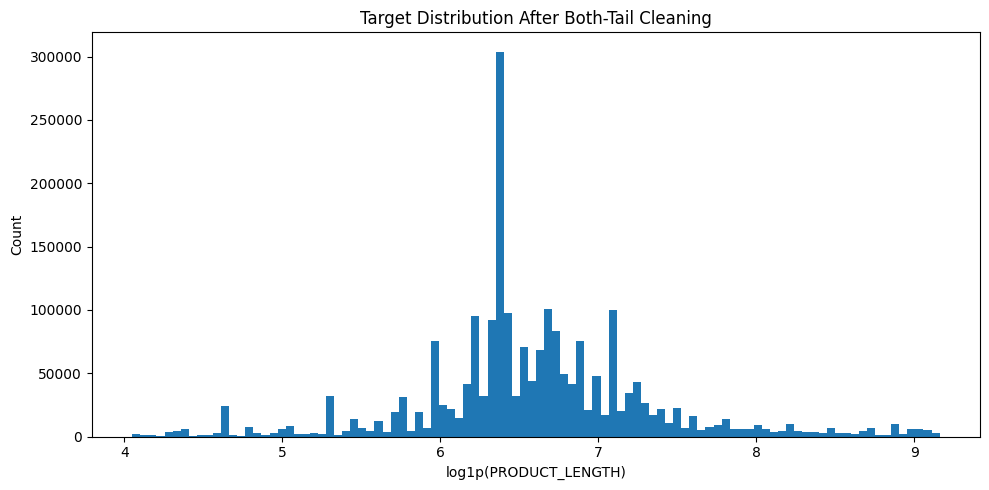

In [15]:

y_clean = train_clean["PRODUCT_LENGTH"].astype(float)

print("Clean target statistics")
print("-----------------------")
print("Minimum :", y_clean.min())
print("Q1      :", y_clean.quantile(0.25))
print("Median  :", y_clean.median())
print("Q3      :", y_clean.quantile(0.75))
print("Maximum :", y_clean.max())
print("Mean    :", y_clean.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(y_clean), bins=100)
ax.set_title("Target Distribution After Both-Tail Cleaning")
ax.set_xlabel("log1p(PRODUCT_LENGTH)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 15. Target buckets after cleaning

In [16]:

post_left_analysis = []

n_clean = len(y_clean)

for t in thresholds:
    count = int((y_clean <= t).sum())
    post_left_analysis.append({
        "threshold": t,
        "count": count,
        "percentage": count / n_clean * 100 if n_clean else 0
    })

post_left_analysis = pd.DataFrame(post_left_analysis)

display(post_left_analysis)


,threshold,count,percentage
0,1,0,0.000000
1,2,0,0.000000
2,3,0,0.000000
3,5,0,0.000000
4,10,0,0.000000
5,20,0,0.000000
6,50,0,0.000000
7,100,48955,2.246560
8,200,118620,5.443509
9,500,501001,22.991094


## 16. Text normalization

In [17]:

ZERO_WIDTH_RE = re.compile(r"[\u200B-\u200D\uFEFF]")
MULTISPACE_RE = re.compile(r"\s+")

def clean_text(s):
    s = s.fillna("").astype("string")
    s = s.str.replace(ZERO_WIDTH_RE, "", regex=True)
    s = s.str.replace("\r", " ", regex=False)
    s = s.str.replace("\n", " ", regex=False)
    s = s.str.replace(MULTISPACE_RE, " ", regex=True)
    s = s.str.strip()
    return s

for col in TEXT_COLS:
    train_clean[col] = clean_text(train_clean[col])
    test[col] = clean_text(test[col])

print("Text normalization complete.")


Text normalization complete.


## 17. Product ID and product type cleaning

In [18]:

bad_train_id = (
    train_clean["PRODUCT_ID"].isna()
    | train_clean["PRODUCT_ID"].str.strip().eq("")
)

bad_test_id = (
    test["PRODUCT_ID"].isna()
    | test["PRODUCT_ID"].str.strip().eq("")
)

print("Invalid train IDs:", bad_train_id.sum())
print("Invalid test IDs :", bad_test_id.sum())

train_clean = train_clean.loc[~bad_train_id].copy()
test = test.loc[~bad_test_id].copy()

# Unknown category rather than dropping the product.
train_clean["PRODUCT_TYPE_ID"] = (
    train_clean["PRODUCT_TYPE_ID"].fillna(-1).astype("int64")
)

test["PRODUCT_TYPE_ID"] = (
    test["PRODUCT_TYPE_ID"].fillna(-1).astype("int64")
)


Invalid train IDs: 0
Invalid test IDs : 0


## 18. Combined text for dimension extraction

In [19]:

def make_combined_text(df):
    return (
        df["TITLE"].fillna("").astype("string") + " " +
        df["BULLET_POINTS"].fillna("").astype("string") + " " +
        df["DESCRIPTION"].fillna("").astype("string")
    ).str.replace(r"\s+", " ", regex=True).str.strip()

train_clean["__TEXT_ALL"] = make_combined_text(train_clean)
test["__TEXT_ALL"] = make_combined_text(test)



## 19. Dimension parser

Extracts:

- `L`
- `W`
- `H`
- `L × W`
- `L × W × H`

and normalizes supported units to centimetres.


In [20]:

NUMBER = r"(\d+(?:\.\d+)?)"
UNIT = r"(mm|millimeters?|cm|centimeters?|m|meters?|in|inch(?:es)?|ft|feet|foot)"
SEP = r"(?:x|×|X|\*)"

DIM_RE = re.compile(
    rf"(?P<a>{NUMBER})\s*(?P<ua>{UNIT})?\s*{SEP}\s*"
    rf"(?P<b>{NUMBER})\s*(?P<ub>{UNIT})?"
    rf"(?:\s*{SEP}\s*(?P<c>{NUMBER})\s*(?P<uc>{UNIT})?)?",
    re.IGNORECASE
)

UNIT_TO_CM = {
    "mm": 0.1,
    "millimeter": 0.1,
    "millimeters": 0.1,
    "cm": 1.0,
    "centimeter": 1.0,
    "centimeters": 1.0,
    "m": 100.0,
    "meter": 100.0,
    "meters": 100.0,
    "in": 2.54,
    "inch": 2.54,
    "inches": 2.54,
    "ft": 30.48,
    "foot": 30.48,
    "feet": 30.48
}

def convert_to_cm(value, unit):
    value = float(value)

    if unit is None:
        return value

    return value * UNIT_TO_CM[unit.lower()]

def parse_dimension(text):
    matches = list(DIM_RE.finditer(str(text)))

    if not matches:
        return np.nan, np.nan, np.nan, 0

    # Prefer a 3-dimensional match.
    matches.sort(
        key=lambda m: (
            m.group("c") is not None,
            m.end() - m.start()
        ),
        reverse=True
    )

    m = matches[0]

    try:
        d1 = convert_to_cm(m.group("a"), m.group("ua"))
        d2 = convert_to_cm(m.group("b"), m.group("ub"))

        if m.group("c") is not None:
            d3 = convert_to_cm(m.group("c"), m.group("uc"))
            return d1, d2, d3, 3

        return d1, d2, np.nan, 2

    except Exception:
        return np.nan, np.nan, np.nan, 0

def extract_dimensions(series):
    parsed = series.map(parse_dimension)

    out = pd.DataFrame(
        parsed.tolist(),
        index=series.index,
        columns=[
            "DIM_1_CM",
            "DIM_2_CM",
            "DIM_3_CM",
            "DIM_COUNT"
        ]
    )

    out["DIM_PRODUCT_2D_CM2"] = (
        out["DIM_1_CM"] * out["DIM_2_CM"]
    )

    out["DIM_VOLUME_CM3"] = (
        out["DIM_1_CM"] *
        out["DIM_2_CM"] *
        out["DIM_3_CM"]
    )

    return out

train_dims = extract_dimensions(train_clean["__TEXT_ALL"])
test_dims = extract_dimensions(test["__TEXT_ALL"])

for col in train_dims.columns:
    train_clean[col] = train_dims[col]
    test[col] = test_dims[col]

display(train_clean[
    [
        "DIM_1_CM",
        "DIM_2_CM",
        "DIM_3_CM",
        "DIM_COUNT",
        "DIM_PRODUCT_2D_CM2",
        "DIM_VOLUME_CM3"
    ]
].head(10))


,DIM_1_CM,DIM_2_CM,DIM_3_CM,DIM_COUNT,DIM_PRODUCT_2D_CM2,DIM_VOLUME_CM3
0,NaN,NaN,NaN,0,NaN,NaN
1,NaN,NaN,NaN,0,NaN,NaN
2,NaN,NaN,NaN,0,NaN,NaN
3,NaN,NaN,NaN,0,NaN,NaN
4,NaN,NaN,NaN,0,NaN,NaN
5,NaN,NaN,NaN,0,NaN,NaN
6,NaN,NaN,NaN,0,NaN,NaN
7,NaN,NaN,NaN,0,NaN,NaN
8,NaN,NaN,NaN,0,NaN,NaN
9,NaN,NaN,NaN,0,NaN,NaN


## 20. Dimension sanity checks

In [21]:

for df in [train_clean, test]:

    for col in ["DIM_1_CM", "DIM_2_CM", "DIM_3_CM"]:

        bad = (
            df[col].notna()
            & (
                ~np.isfinite(df[col])
                | (df[col] <= 0)
                | (df[col] > MAX_DIMENSION_CM)
            )
        )

        df.loc[bad, col] = np.nan

    df["DIM_PRODUCT_2D_CM2"] = (
        df["DIM_1_CM"] * df["DIM_2_CM"]
    )

    df["DIM_VOLUME_CM3"] = (
        df["DIM_1_CM"] *
        df["DIM_2_CM"] *
        df["DIM_3_CM"]
    )

print("Dimension sanity checks complete.")


Dimension sanity checks complete.


## 21. Product-type-aware dimension imputation

In [22]:

DIM_COLS = ["DIM_1_CM", "DIM_2_CM", "DIM_3_CM"]

global_dim_medians = {}
ptype_dim_medians = {}

for col in DIM_COLS:

    global_median = train_clean[col].median()

    if not np.isfinite(global_median):
        global_median = 1.0

    global_dim_medians[col] = float(global_median)

    medians = (
        train_clean
        .groupby("PRODUCT_TYPE_ID")[col]
        .median()
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    ptype_dim_medians[col] = {
        str(k): float(v)
        for k, v in medians.items()
    }

    train_clean[col] = train_clean[col].fillna(
        train_clean["PRODUCT_TYPE_ID"].map(medians)
    )

    test[col] = test[col].fillna(
        test["PRODUCT_TYPE_ID"].map(medians)
    )

    train_clean[col] = train_clean[col].fillna(global_median)
    test[col] = test[col].fillna(global_median)

for df in [train_clean, test]:

    df["DIM_PRODUCT_2D_CM2"] = (
        df["DIM_1_CM"] * df["DIM_2_CM"]
    )

    df["DIM_VOLUME_CM3"] = (
        df["DIM_1_CM"] *
        df["DIM_2_CM"] *
        df["DIM_3_CM"]
    )

print("Dimension imputation complete.")


Dimension imputation complete.


## 22. Dimension availability flags

In [23]:

train_clean["HAS_DIMENSION_2D"] = (
    train_dims["DIM_COUNT"] >= 2
).astype("int8")

train_clean["HAS_DIMENSION_3D"] = (
    train_dims["DIM_COUNT"] >= 3
).astype("int8")

test["HAS_DIMENSION_2D"] = (
    test_dims["DIM_COUNT"] >= 2
).astype("int8")

test["HAS_DIMENSION_3D"] = (
    test_dims["DIM_COUNT"] >= 3
).astype("int8")

print("Dimension flags added.")


Dimension flags added.


## 23. Text quality features

In [24]:

def add_text_quality_features(df):

    for col, prefix in [
        ("TITLE", "TITLE"),
        ("BULLET_POINTS", "BULLET"),
        ("DESCRIPTION", "DESC")
    ]:

        s = df[col].fillna("").astype("string")

        df[f"{prefix}_CHAR_COUNT"] = (
            s.str.len().fillna(0).astype("int32")
        )

        df[f"{prefix}_WORD_COUNT"] = (
            s.str.split().str.len().fillna(0).astype("int32")
        )

        df[f"{prefix}_DIGIT_COUNT"] = (
            s.str.count(r"\d").fillna(0).astype("int32")
        )

        df[f"{prefix}_EMPTY"] = (
            s.str.strip().eq("").astype("int8")
        )

    return df

train_clean = add_text_quality_features(train_clean)
test = add_text_quality_features(test)


## 24. Measurement-unit indicators

In [25]:

UNIT_RE = re.compile(
    r"\b(?:mm|millimeters?|cm|centimeters?|m|meters?|"
    r"in|inch(?:es)?|ft|feet|foot|kg|g|lb|lbs|oz)\b",
    re.IGNORECASE
)

for df in [train_clean, test]:

    df["HAS_MEASUREMENT_UNIT"] = (
        df["__TEXT_ALL"]
        .fillna("")
        .astype("string")
        .str.contains(UNIT_RE, regex=True, na=False)
        .astype("int8")
    )

print("Measurement indicators added.")


Measurement indicators added.


## 25. Train/test leakage checks

In [26]:

overlap = (
    set(train_clean["PRODUCT_ID"])
    & set(test["PRODUCT_ID"])
)

print("Train/Test PRODUCT_ID overlap:", len(overlap))

assert len(overlap) == 0
assert train_clean["PRODUCT_ID"].is_unique
assert test["PRODUCT_ID"].is_unique

assert "PRODUCT_LENGTH" not in test.columns

assert train_clean["PRODUCT_LENGTH"].notna().all()
assert np.isfinite(train_clean["PRODUCT_LENGTH"]).all()
assert (train_clean["PRODUCT_LENGTH"] > 0).all()

print("Leakage checks PASSED.")


Train/Test PRODUCT_ID overlap: 0
Leakage checks PASSED.


## 26. Final data-quality report

In [27]:

def quality_report(df, name, target=False):

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    print("Duplicate PRODUCT_ID:", df["PRODUCT_ID"].duplicated().sum())

    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    print("\nMissing values:")
    if len(missing):
        display(missing.to_frame("count"))
    else:
        print("None")

    if target:

        y = df["PRODUCT_LENGTH"]

        print("\nTarget statistics:")
        print("min    :", y.min())
        print("Q1     :", y.quantile(0.25))
        print("median :", y.median())
        print("Q3     :", y.quantile(0.75))
        print("max    :", y.max())
        print("mean   :", y.mean())

quality_report(train_clean, "CLEAN TRAIN", target=True)
quality_report(test, "CLEAN TEST", target=False)


CLEAN TRAIN
Shape: (2179109, 28)
Duplicate rows: 0
Duplicate PRODUCT_ID: 0

Missing values:
None

Target statistics:
min    : 56.41721
Q1     : 531.495
median : 669.2913379
Q3     : 1060.0
max    : 9500.0
mean   : 1013.5418703063393
CLEAN TEST
Shape: (734736, 27)
Duplicate rows: 0
Duplicate PRODUCT_ID: 0

Missing values:
None


## 27. Cleaning summary

In [28]:

reason_summary = (
    audit[audit["removed"]]
    ["reason"]
    .value_counts()
    .rename_axis("reason")
    .reset_index(name="count")
)

reason_summary["percentage_of_raw_train"] = (
    reason_summary["count"] / len(train) * 100
)

display(reason_summary)

print("\nTotal removed:", audit["removed"].sum())
print("Final train  :", len(train_clean))


,reason,count,percentage_of_raw_train
0,extreme_left_target_outlier,46578,2.070411
1,extreme_right_target_outlier,24011,1.067299



Total removed: 70589
Final train  : 2179109


## 28. Save cleaning rules

In [29]:

rules = {
    "data_mode": DATA_MODE,

    "target": {
        "column": "PRODUCT_LENGTH",
        "transform": "log1p",
        "left_rule": "Q1 - 3*IQR",
        "right_rule": "Q3 + 3*IQR",
        "log_q1": q1_log,
        "log_q3": q3_log,
        "log_iqr": iqr_log,
        "robust_lower": robust_lower,
        "robust_upper": robust_upper,
        "final_lower": final_lower,
        "final_upper": final_upper
    },

    "duplicates": {
        "exact_rows": "keep_first",
        "PRODUCT_ID": "keep_first"
    },

    "dimensions": {
        "unit": "cm",
        "max_dimension_cm": MAX_DIMENSION_CM,
        "imputation": "PRODUCT_TYPE_ID median -> global training median -> 1.0"
    },

    "text": {
        "missing_to_empty": True,
        "remove_zero_width_characters": True,
        "normalize_whitespace": True,
        "strip": True
    }
}

with open(RULES_FILE, "w", encoding="utf-8") as f:
    json.dump(rules, f, indent=2)

print("Saved:", RULES_FILE)


Saved: ../dataset/cleaned\cleaning_rules_full.json


## 29. Remove internal parser text

In [30]:
train_clean = train_clean.drop(columns=["__TEXT_ALL"])
test = test.drop(columns=["__TEXT_ALL"])

print("Internal helper column removed.")


Internal helper column removed.


## 30. Save final clean datasets and audit

In [31]:

train_clean.to_csv(CLEAN_TRAIN_FILE, index=False)
test.to_csv(CLEAN_TEST_FILE, index=False)

audit_to_save = audit.copy()
audit_to_save["original_row_index"] = audit_to_save.index

audit_to_save.to_csv(AUDIT_FILE, index=False)

print("Files written:")
print("  ", CLEAN_TRAIN_FILE)
print("  ", CLEAN_TEST_FILE)
print("  ", AUDIT_FILE)
print("  ", RULES_FILE)


Files written:
   ../dataset/cleaned\train_clean_full.csv
   ../dataset/cleaned\test_clean_full.csv
   ../dataset/cleaned\cleaning_audit_full.csv
   ../dataset/cleaned\cleaning_rules_full.json



# Notebook 02 Complete

```text
Raw data
   ↓
Cleaning
   ├── invalid records
   ├── duplicates
   ├── left-tail anomalies
   └── right-tail anomalies
   ↓
Text normalization
   ↓
Dimension extraction
   ↓
Dimension normalization
   ↓
Clean dataset
   ↓
Notebook 03 / NLP
```